# ReCUE paper figures

Two headline figures from the cached 30-cell headline results, styled to match
the project figure conventions (Times serif, large fonts, thick marks, ticks-in,
`usetex`). Data: `$EXP_ROOT/{headline_v2,rc_cells}.json`.

* **Fig A - compute-quality Pareto** (`pareto_quality.pdf`)
* **Fig B - macro risk-coverage** (`risk_coverage.pdf`)

In [10]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

repo = Path.cwd().resolve()
if repo.name == 'visualization':
    repo = repo.parent
sys.path.insert(0, str(repo))
from recue.env import EXP_ROOT

OUT = repo / 'latex' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

# ---- figure style (matches SpatialMind/analysis/v3.ipynb) ----
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'figure.dpi': 300,
    'savefig.dpi': 320,
    'font.size': 21,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'legend.fontsize': 19,
    'axes.linewidth': 2.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.usetex'] = True

# Okabe-Ito colorblind-safe palette
C_RECUE = '#D55E00'   # vermillion : ReCUE (ours)
C_SC    = '#0072B2'   # blue       : self-consistency
C_SINGLE= '#999999'   # gray       : cheap single-trace baselines
C_FUSE  = '#CC79A7'   # purple     : fusion
C_PT    = '#009E73'   # green      : P(True)
MUTED, GRID = '#888888', '#cfcfcf'

def savefig(fig, name):
    fig.savefig(OUT / f'{name}.pdf', bbox_inches='tight')

macro = {r: v['macro_auroc'] for r, v in
         json.loads((EXP_ROOT / 'headline_v2.json').read_text())['table'].items()}
print('rows:', sorted(macro))

rows: ['active', 'arc+multi', 'deepconf', 'full', 'full+multi', 'full+sc8', 'mean_logprob', 'multidepth', 'passive', 'ptrue', 'sc8', 'self_certainty']


## Fig A - compute-quality Pareto
Relative latency vs macro AUROC. ReCUE (star) reaches the SC@8-quality line at
$1.03\times$ cost; fusion extends the frontier at a matched 8$\times$ budget.

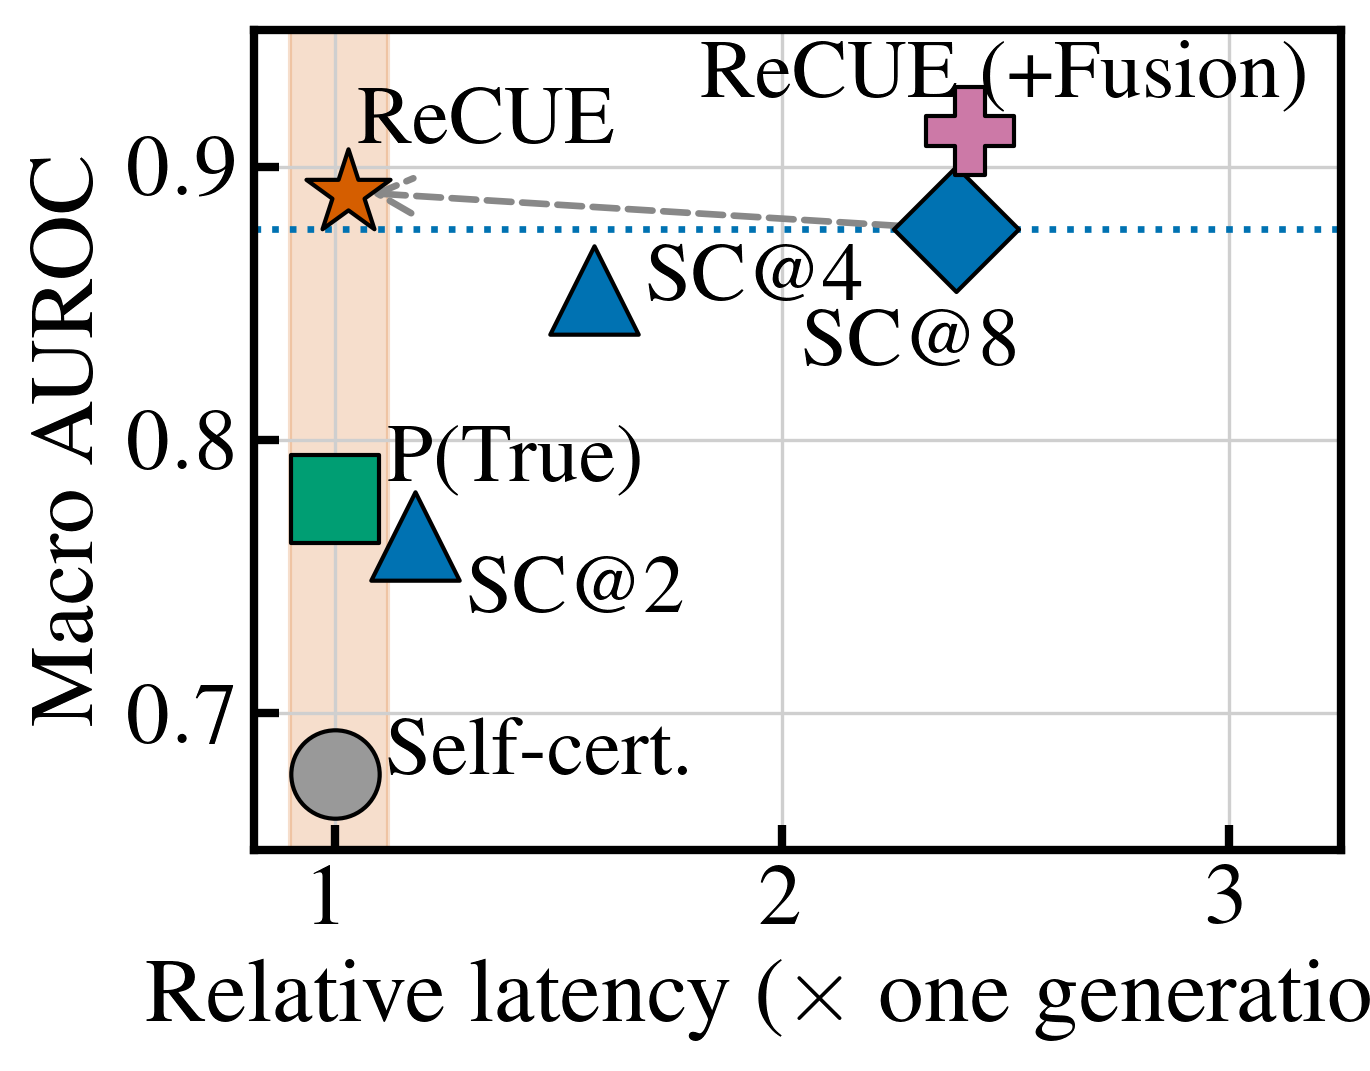

saved pareto_quality.pdf


In [11]:
# (label, macro AUROC, relative latency, color, marker, ours)
pts = [
    ('Self-cert.',   macro['self_certainty'], 1.00, C_SINGLE, 'o', False),
    ('P(True)',      macro['ptrue'],          1.00, C_PT,     's', False),
    ('SC@2',         0.765,                   1.18, C_SC,     '^', False),
    ('SC@4',         0.855,                   1.58, C_SC,     '^', False),
    ('SC@8',         macro['sc8'],            2.39, C_SC,     'D', False),
    ('ReCUE',        macro['full'],           1.03, C_RECUE,  '*', True),
    ('ReCUE (+Fusion)',   macro['full+sc8'],       2.42, C_FUSE,   'P', True),
]
fig, ax = plt.subplots(figsize=(5, 4))
sc8 = macro['sc8']
ax.axhline(sc8, color=C_SC, lw=1.6, ls=':', zorder=1)
# ax.text(2.9, sc8 - 0.006, r'SC@8 quality', color=C_SC, fontsize=16, ha='right', va='top')
ax.axvspan(0.90, 1.12, color=C_RECUE, alpha=0.2, zorder=0)
lbl = {'ReCUE':(0.6,0.018,'right'), 'SC@8':(0.15,-0.05,'right'),
       'ReCUE (+Fusion)':(-0.6,0.012,'left'), 'P(True)':(0.12,0.006,'left'),
       'SC@2':(0.12,-0.028,'left'), 'Self-cert.':(0.12,0.0,'left'),
       'SC@4':(0.12,-0.004,'left')}
for label, au, lat, col, mk, ours in pts:
    ax.scatter(lat, au, s=450, c=col, marker=mk,
               edgecolor='black', linewidth=1.0, zorder=5)
    dx, dy, ha = lbl.get(label, (0.07, 0.0, 'left'))
    ax.annotate(label, (lat, au), (lat + dx, au + dy), ha=ha, fontsize=20, color='black')
ax.annotate('', xy=(1.06, macro['full']), xytext=(2.36, sc8),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.6, ls='--'))
# ax.text(1.72, 0.912, r'$\approx$ quality, $\sim\!1/8$ cost', fontsize=15,
#         color=MUTED, ha='center')
ax.set_xlabel(r'Relative latency ($\times$ one generation)')
ax.set_ylabel(r'Macro AUROC')
ax.set_xlim(0.82, 3.25); ax.set_ylim(0.65, 0.95)
ax.tick_params(width=2.0, length=6)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
fig.tight_layout()
savefig(fig, 'pareto_quality')
plt.show()
print('saved pareto_quality.pdf')

## Fig B - macro risk-coverage curves
Cell-equal macro over 30 headline cells. ReCUE (1$\times$) tracks SC@8 and lies
far below the single-trace baselines.

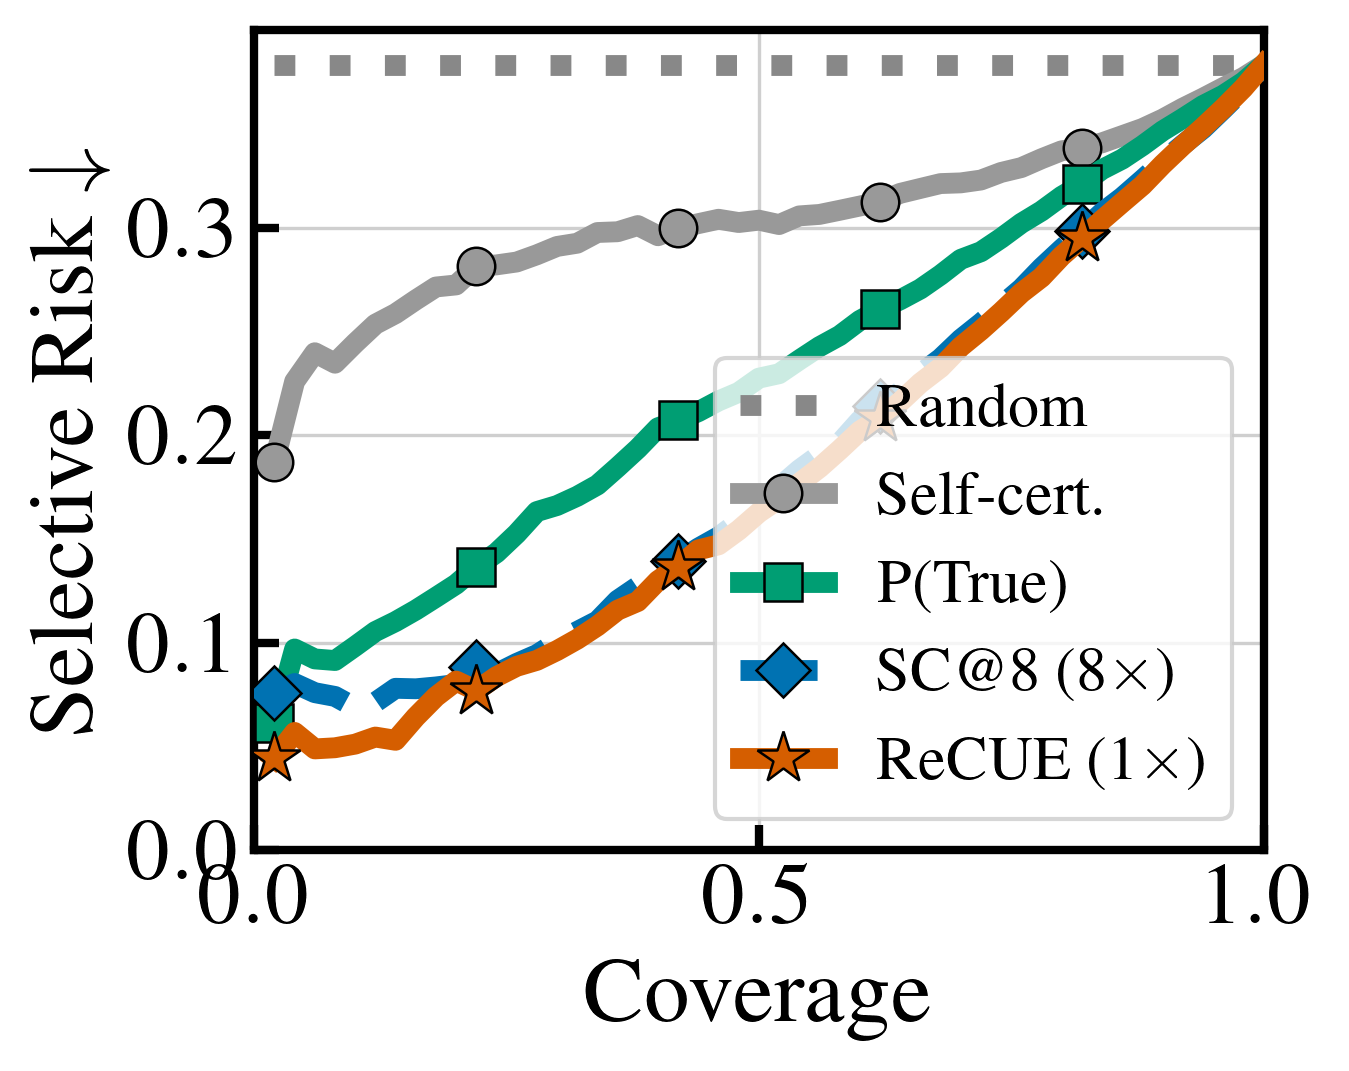

saved risk_coverage.pdf  (area: ReCUE 0.182, SC@8 0.188)


In [12]:
cells_rc = json.loads((EXP_ROOT / 'rc_cells.json').read_text())
GRID_C = np.linspace(0.02, 1.0, 50)

def rc_curve(key):
    curves = []
    for d in cells_rc.values():
        s = d.get(key)
        if s is None:
            continue
        s = np.array(s, float); y = np.array(d['y'], float)
        order = np.argsort(-s); err = 1.0 - y[order]
        cum = np.cumsum(err) / (np.arange(len(err)) + 1)
        idx = np.clip((GRID_C * len(err)).astype(int) - 1, 0, len(err) - 1)
        curves.append(cum[idx])
    return np.mean(curves, axis=0)

rnd = np.full_like(GRID_C, np.mean([1 - np.mean(d['y']) for d in cells_rc.values()]))
recue, sc8c, pt, sc_ = (rc_curve(k) for k in ['recue', 'sc8', 'ptrue', 'selfcert'])

fig, ax = plt.subplots(figsize=(5, 4))
series = [
    (rnd,  MUTED,    'Random',            5, ':',  None),
    (sc_,  C_SINGLE, 'Self-cert.',        5, '-',  'o'),
    (pt,   C_PT,     r'P(True)',          5, '-',  's'),
    (sc8c, C_SC,     r'SC@8 (8$\times$)', 5, '--', 'D'),
    (recue,C_RECUE,  r'ReCUE (1$\times$)',5, '-',  '*'),
]
for c, col, lab, lw, ls, mk in series:
    ax.plot(GRID_C, c, color=col, lw=lw, ls=ls, label=lab, zorder=5 if mk=='*' else 3,
            marker=mk, markersize=13 if mk=='*' else 9, markevery=10,
            markeredgecolor='black', markeredgewidth=0.6)
ax.set_xlabel(r'Coverage')
ax.set_ylabel(r'Selective Risk $\downarrow$')
ax.set_xlim(0, 1.0); ax.set_ylim(0, None)
ax.tick_params(width=2.0, length=6)
ax.legend(loc='lower right', frameon=True, handlelength=1.4, fontsize=15, ncol=1)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
fig.tight_layout()
savefig(fig, 'risk_coverage')
plt.show()
print(f'saved risk_coverage.pdf  (area: ReCUE {recue.mean():.3f}, SC@8 {sc8c.mean():.3f})')